Create Visualization Notebook

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("../src"))

from bingham_model import bingham_shear_stress

Generate Shear Rate Curve

In [2]:
yield_stress = 5
plastic_viscosity = 0.02

shear_rates = np.linspace(0, 500, 100)

shear_stress = bingham_shear_stress(
    yield_stress,
    plastic_viscosity,
    shear_rates
)

Plot Rheology Curve

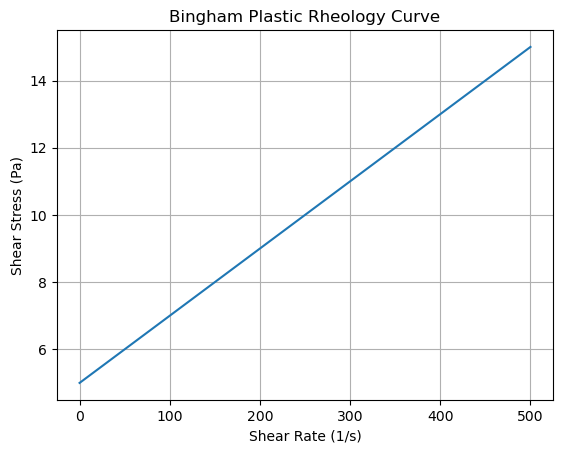

In [3]:
plt.figure()

plt.plot(shear_rates, shear_stress)

plt.xlabel("Shear Rate (1/s)")
plt.ylabel("Shear Stress (Pa)")
plt.title("Bingham Plastic Rheology Curve")

plt.grid(True)
plt.savefig("../results/bingham_rheology_curve.png", dpi=300)

plt.show()

Update Notebook

In [4]:
from bingham_model import calculate_bingham_parameters

theta600 = 45
theta300 = 30

PV, YP = calculate_bingham_parameters(theta600, theta300)

print("Plastic Viscosity:", PV)
print("Yield Point:", YP)

Plastic Viscosity: 15
Yield Point: 15


Connect to Rheology Curve
      Then generate the rheology curve again which looks like actual rig data.

In [5]:
from bingham_model import convert_yp_to_pascal

yield_stress = convert_yp_to_pascal(YP)  # converts the Yield Point (YP) from field units (lb/100ft²) to the SI unit of stress, Pascals (Pa)

plastic_viscosity = PV / 1000         # converts the Plastic Viscosity (PV) from field units (centipoise, cP) to Pascal-seconds (Pa·s)


In [6]:
shear_rates = np.linspace(0, 500, 100)

shear_stress = bingham_shear_stress(
    yield_stress,
    plastic_viscosity,
    shear_rates
)

Plot Actual Rig Rheology Curve

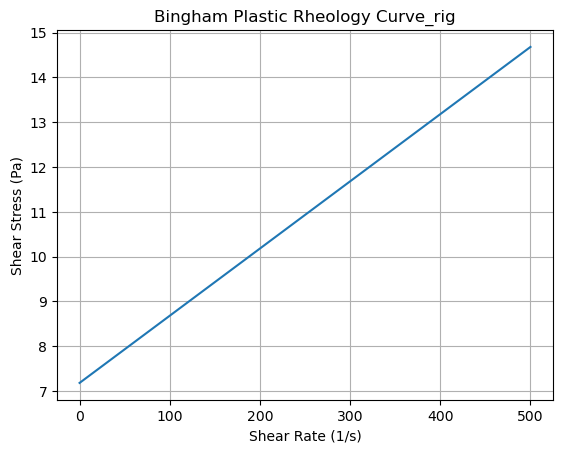

In [7]:
plt.figure()

plt.plot(shear_rates, shear_stress)

plt.xlabel("Shear Rate (1/s)")
plt.ylabel("Shear Stress (Pa)")
plt.title("Bingham Plastic Rheology Curve_rig")

plt.grid(True)
plt.savefig("../results/bingham_rheology_curve_rig.png", dpi=300)

plt.show()

Objective: Compare rheology curves of multiple drilling fluids using Bingham parameters.

Define Mud Samples

In [8]:
mud_samples = [
    {"name": "Mud A", "theta600": 45, "theta300": 30},
    {"name": "Mud B", "theta600": 50, "theta300": 32},
    {"name": "Mud C", "theta600": 40, "theta300": 25},
]     #Create a list of muds with viscometer readings

Compute Bingham Parameters

In [9]:
results = [] # creating a list of computed bingham parameters

for mud in mud_samples:
    PV, YP = calculate_bingham_parameters(mud["theta600"], mud["theta300"])
    yield_stress = convert_yp_to_pascal(YP)
    plastic_viscosity = PV / 1000  # Convert to Pa.s (SI Units)
    results.append({
        "name": mud["name"],
        "yield_stress": yield_stress,
        "plastic_viscosity": plastic_viscosity
    })

In [10]:
print(results)

[{'name': 'Mud A', 'yield_stress': 7.182, 'plastic_viscosity': 0.015}, {'name': 'Mud B', 'yield_stress': 6.7032, 'plastic_viscosity': 0.018}, {'name': 'Mud C', 'yield_stress': 4.788, 'plastic_viscosity': 0.015}]


Generate Shear Rate Array

In [11]:
shear_rates = np.linspace(0, 500, 100)

Compute Rheology Curves

In [12]:
curves = {}  # create an empty set to store the parameters to plot

for mud in results:
    stresses = bingham_shear_stress(
        mud["yield_stress"],
        mud["plastic_viscosity"],
        shear_rates
    )
    curves[mud["name"]] = stresses

Plot Comparative Curves

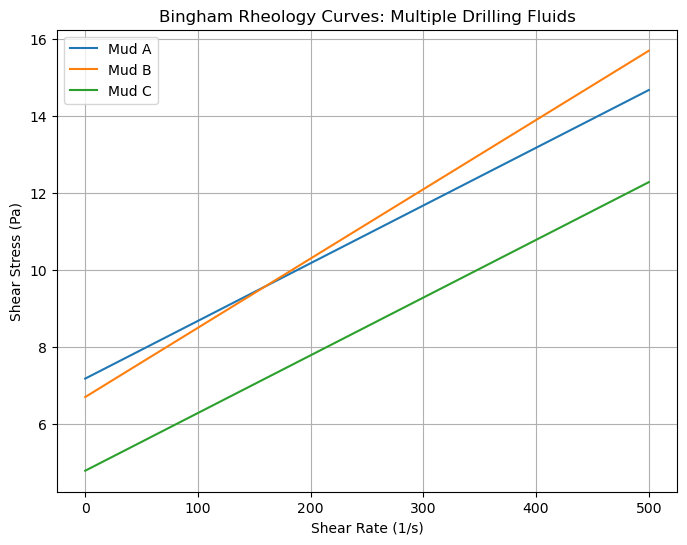

In [13]:
plt.figure(figsize=(8,6))

for name, stresses in curves.items():
    plt.plot(shear_rates, stresses, label=name)

plt.xlabel("Shear Rate (1/s)")
plt.ylabel("Shear Stress (Pa)")
plt.title("Bingham Rheology Curves: Multiple Drilling Fluids")
plt.legend()
plt.grid(True)
plt.savefig("../results/multiple_mud_rheology_comparison.png", dpi=300)
plt.show()

Import Temperature Model

In [14]:
import sys
import os

sys.path.append(os.path.abspath("../../week_01_temperature_corrected_rheology/src"))


from temperature_model import correct_viscosity   # to have access to the Arrhenius correction function you built earlier

Define Temperature Conditions

In [15]:
surface_temp = 30      # Celsius
downhole_temp = 120    # Celsius

activation_energy = 25000  # J/mol

Apply Temperature Correction

In [16]:
corrected_results = []    # to compute downhole-corrected viscosity

for mud in mud_samples:

    PV, YP = calculate_bingham_parameters(
        mud["theta600"],
        mud["theta300"]
    )

    yield_stress = convert_yp_to_pascal(YP)

    # convert PV to Pa.s
    plastic_viscosity_surface = PV / 1000

    plastic_viscosity_downhole = correct_viscosity(
        plastic_viscosity_surface,
        surface_temp,
        downhole_temp,
        activation_energy
    )

    corrected_results.append({
        "name": mud["name"],
        "yield_stress": yield_stress,
        "plastic_viscosity": plastic_viscosity_downhole
    })

Generate Corrected Rheology Curves

In [17]:
shear_rates = np.linspace(0, 500, 100)

corrected_curves = {}

for mud in corrected_results:

    stresses = bingham_shear_stress(
        mud["yield_stress"],
        mud["plastic_viscosity"],
        shear_rates
    )

    corrected_curves[mud["name"]] = stresses

Plot Temperature-Corrected Curves

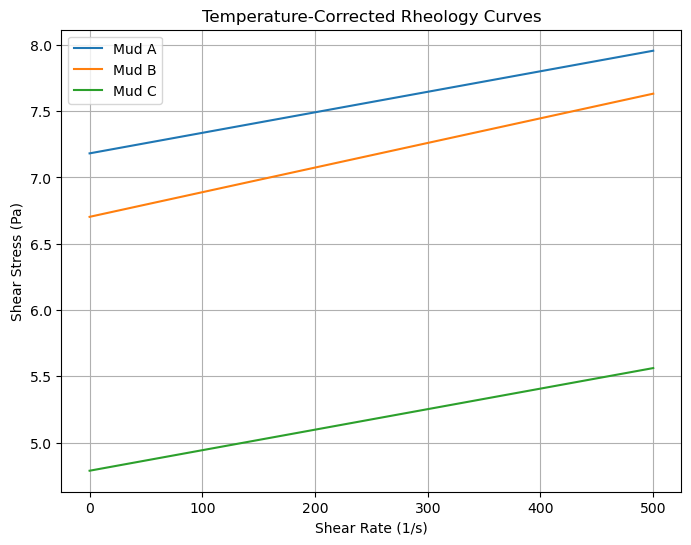

In [18]:
plt.figure(figsize=(8,6))

for name, stresses in corrected_curves.items():
    plt.plot(shear_rates, stresses, label=name)

plt.xlabel("Shear Rate (1/s)")
plt.ylabel("Shear Stress (Pa)")
plt.title("Temperature-Corrected Rheology Curves")
plt.legend()
plt.grid(True)
plt.savefig("../results/temperature_corrected_rheology.png", dpi=300)
plt.show()

Temperature Effect on Rheology Intepretation

As downhole temperature increases, plastic viscosity decreases due to thermal thinning of the drilling fluid.

This results in:

- Reduced shear stress
- Lower pressure losses
- Lower equivalent circulating density (ECD)

Temperature corrections are therefore critical for realistic hydraulic modelling.

Import Hydraulics Module

In [19]:
sys.path.append(os.path.abspath("../src"))

from hydraulics_model import annular_pressure_loss

Define Well Geometry

In [20]:
hole_diameter = 0.216  # 8.5 inch hole (m)
pipe_diameter = 0.127  # 5 inch drill pipe (m)

flow_rate = 0.03  # m3/s

Calculate Pressure Loss for Each Mud

In [21]:
pressure_results = []

for mud in corrected_results:

    pressure_grad = annular_pressure_loss(
        mud["plastic_viscosity"],
        mud["yield_stress"],
        flow_rate,
        hole_diameter,
        pipe_diameter
    )

    pressure_results.append({
        "name": mud["name"],
        "pressure_gradient": pressure_grad
    })

Display Results

In [22]:
for r in pressure_results:
    print(r["name"], "Pressure Gradient (Pa/m):", r["pressure_gradient"])

# Now you are seeing how different mud rheologies change pressure loss.

# That is exactly the sort of calculation used when engineers adjust pump rates or mud properties.

Mud A Pressure Gradient (Pa/m): 330.61473758637385
Mud B Pressure Gradient (Pa/m): 310.66128060926656
Mud C Pressure Gradient (Pa/m): 223.0192319683963


Engineering Interpretation

              Hydraulic Impact of Rheology

Higher plastic viscosity increases viscous pressure losses.

Higher yield stress increases pressure losses even at low shear rates.

Both parameters directly influence circulating pressure and ECD.

Save Results

In [23]:
import pandas as pd

df = pd.DataFrame(pressure_results)

df.to_csv("../results/annular_pressure_results.csv", index=False)

Import Function

In [24]:
from hydraulics_model import calculate_ecd

Define Well Parameters

In [25]:
mud_weight = 12.0   # ppg
tvd = 3000          # meters

Calculate ECD for Each Mud

In [26]:
ecd_results = []

for i, mud in enumerate(corrected_results):

    pressure_grad = pressure_results[i]["pressure_gradient"]

    ecd = calculate_ecd(
        mud_weight,
        pressure_grad,
        tvd
    )

    ecd_results.append({
        "name": mud["name"],
        "ECD_ppg": ecd
    })

Display Results

In [27]:
for r in ecd_results:
    print(r["name"], "ECD (ppg):", round(r["ECD_ppg"], 2)) # how mud rheology affects circulating density.

# This is literally the calculation engineers watch during circulation.

Mud A ECD (ppg): 12.28
Mud B ECD (ppg): 12.26
Mud C ECD (ppg): 12.19


Save Results

In [28]:
df = pd.DataFrame(ecd_results)

df.to_csv("../results/ecd_results.csv", index=False)


                        ECD Interpretation

Equivalent Circulating Density represents the effective density of the drilling fluid while circulating.

Higher rheology increases annular pressure losses, which increases ECD.

If ECD exceeds fracture gradient, formation losses may occur. Accurate hydraulic modelling is therefore critical for safe drilling operations.

Create Depth Array

In [29]:
depths = np.linspace(0, 3000, 100)  # meters. This simulates a well from surface to 3000 m TVD.

Compute Pressure Along Depth

In [30]:
ecd_profiles = {}

for i, mud in enumerate(corrected_results):       # every mud has an ECD profile along the well.

    pressure_grad = pressure_results[i]["pressure_gradient"]

    ecd_values = []

    for d in depths:   # calculates ecd at different depths

        ecd = calculate_ecd(
            mud_weight,
            pressure_grad,
            d if d > 1 else 1   # avoid division by zero
        )

        ecd_values.append(ecd)

    ecd_profiles[mud["name"]] = ecd_values

Plot ECD vs Depth

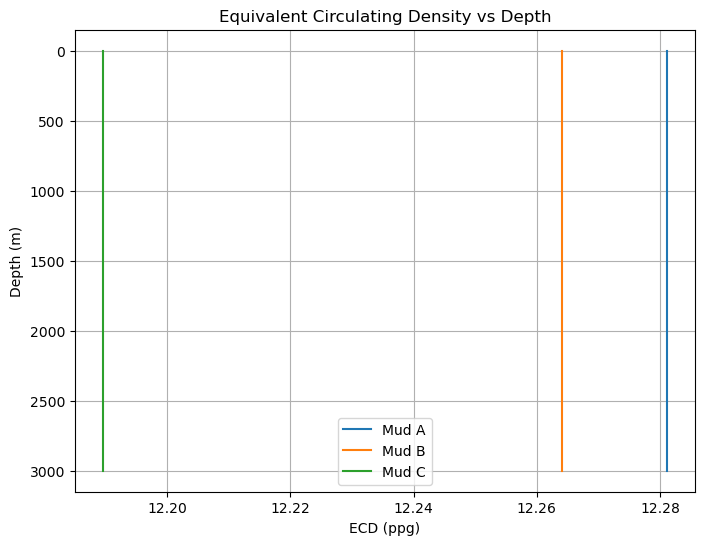

In [34]:
plt.figure(figsize=(8,6))

for name, values in ecd_profiles.items():
    plt.plot(values, depths, label=name)

plt.gca().invert_yaxis()  # Engineers plot depth downwards, so we invert the axis. Now you have a real wellbore hydraulics plot.

plt.xlabel("ECD (ppg)")
plt.ylabel("Depth (m)")
plt.title("Equivalent Circulating Density vs Depth")

plt.legend()
plt.grid(True)
plt.savefig("../results/ecd_depth_profile.png", dpi=300)
plt.show()

Save Numerical Results of Equivalent Circulating Density vs Depth

In [35]:
df_depth = pd.DataFrame(ecd_profiles)
df_depth["Depth_m"] = depths

df_depth.to_csv("../results/ecd_depth_profiles.csv", index=False)

                               ECD Depth Profile Interpretation

Equivalent Circulating Density increases with depth because pressure losses accumulate along the wellbore.

Fluids with higher rheology produce higher ECD values, which may approach or exceed fracture limits.

This simulation allows engineers to evaluate the hydraulic impact of different drilling fluid systems.

ECD should not remain perfectly constant with depth in a realistic well. In reality the pressure gradient changes along the well because of things like:

a) Temperature changes with depth

b) Viscosity changes with temperature

c) Cuttings loading

d) Annular velocity variations

e) Pipe rotation effects

f) Different hole sections

Your model currently assumes:

a) constant rheology
b) constant temperature
c) constant geometry
d) constant flow regime

So the hydraulics never change.

                     The Fix for Your Project

For your simulator, the cleanest improvement is:

     # Make viscosity change with depth using temperature gradient.

That automatically makes pressure gradient change. So the ECD profile becomes curved instead of flat.

Define geothermal gradient

In [39]:
surface_temp = 30
geothermal_gradient = 0.03   # °C per meter

Depth array

In [40]:
depths = np.linspace(1, 3000, 120)

Compute ECD with temperature variation

In [41]:
ecd_profiles = {}

for mud in mud_samples:

    PV, YP = calculate_bingham_parameters(
        mud["theta600"],
        mud["theta300"]
    )

    yield_stress = convert_yp_to_pascal(YP)
    plastic_viscosity_surface = PV / 1000

    ecd_values = []

    for depth in depths:

        temp_downhole = surface_temp + geothermal_gradient * depth

        mu_downhole = correct_viscosity(
            plastic_viscosity_surface,
            surface_temp,
            temp_downhole,
            activation_energy
        )

        pressure_grad = annular_pressure_loss(
            mu_downhole,
            yield_stress,
            flow_rate,
            hole_diameter,
            pipe_diameter
        )

        ecd = calculate_ecd(
            mud_weight,
            pressure_grad,
            depth
        )

        ecd_values.append(ecd)

    ecd_profiles[mud["name"]] = ecd_values

Plot

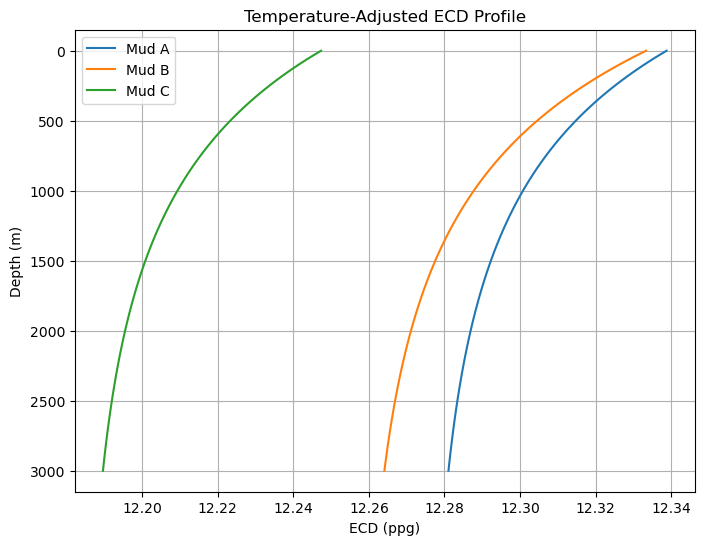

In [43]:
plt.figure(figsize=(8,6))

for name, values in ecd_profiles.items():
    plt.plot(values, depths, label=name)

plt.gca().invert_yaxis()

plt.xlabel("ECD (ppg)")
plt.ylabel("Depth (m)")
plt.title("Temperature-Adjusted ECD Profile")

plt.legend()
plt.grid(True)
plt.savefig("../results/ecd_depth_profiles_temp_corrected.png", dpi=300)
plt.show()

Now you should see:

• slight curvature
• ECD changing gradually with depth
• differences between mud systems becoming clearer

Because viscosity decreases with temperature, which is exactly what happens in hot wells.

Save Numerical Results

In [44]:
df_depth = pd.DataFrame(ecd_profiles)
df_depth["Depth_m"] = depths

df_depth.to_csv("../results/ecd_depth_profiles_temp_corrected.csv", index=False)